# ResNet50 + ImageNet Normalisation — Joint Regression

**ResNet50 with ImageNet pre-trained weights and 3-channel input.**

Key differences from `joint_regression.ipynb`:
- **3-channel input**: grayscale repeated → 3 identical channels (RGB contract)
- **ImageNet normalisation**: after p1/p99 clip to [0,1], apply `(x − μ) / σ`
  with μ = [0.485, 0.456, 0.406], σ = [0.229, 0.224, 0.225]
- **Pre-trained weights**: `ResNet50_Weights.IMAGENET1K_V2` — no need to learn low-level features from scratch
- **No conv1 modification**: original 3-channel conv is kept and pre-trained
- **Final cell**: runs inference on FITS observational images using the same preprocessing

Training strategy: freeze all layers except the head for the first N epochs, then unfreeze.

In [1]:
# Cell 1 — Imports & config
from pathlib import Path
import json, time, sys
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from torchvision.models import ResNet50_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import multiprocessing as mp

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

DATA_FILE  = PROJECT_ROOT / 'data' / 'raw' / 'uniform_kmin_128x128_100000.h5'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'comparison' / 'resnet_imagenet_norm'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparams ────────────────────────────────────────────────────────────
SEED          = 42
IMG_SIZE      = 128
EPOCHS_FROZEN = 5         # head-only warm-up
EPOCHS_FULL   = 45        # fine-tune all layers
EPOCHS        = EPOCHS_FROZEN + EPOCHS_FULL
BATCH_SIZE    = 32
LR_HEAD       = 1e-3
LR_FINE       = 1e-4
NUM_WORKERS   = max(1, mp.cpu_count() - 1)

# ── Target normalisation (same as joint_regression) ────────────────────────
KMIN_LO, KMIN_HI = 1.0,  62.0
KMAX_LO, KMAX_HI = 5.0,  64.0
LOG_SIG_LO        = float(np.log(0.01))
LOG_SIG_HI        = float(np.log(5.0))

# ── ImageNet normalisation ─────────────────────────────────────────────────
IN_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
IN_STD  = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Project : {PROJECT_ROOT}')
print(f'Data    : {DATA_FILE}')
print(f'Output  : {OUTPUT_DIR}')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

Project : /home/davas/Documents/cnn_astro
Data    : /home/davas/Documents/cnn_astro/data/raw/uniform_kmin_128x128_100000.h5
Output  : /home/davas/Documents/cnn_astro/outputs/comparison/resnet_imagenet_norm
Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [2]:
# Cell 2 — Load labels and compute global percentiles
with h5py.File(DATA_FILE, 'r') as hf:
    n_total    = hf['images'].shape[0]
    kmin_vals  = hf['parameters']['k_min'][:]
    kmax_vals  = hf['parameters']['k_max'][:]
    sigma_vals = hf['parameters']['sigma'][:]

np.random.seed(SEED)
samp_idx = np.sort(np.random.choice(n_total, 2000, replace=False))
with h5py.File(DATA_FILE, 'r') as hf:
    samp = hf['images'][samp_idx]
IMG_P1  = float(np.percentile(samp, 1))
IMG_P99 = float(np.percentile(samp, 99))
del samp

print(f'N = {n_total:,}')
print(f'Global percentiles:  p1={IMG_P1:.4f}  p99={IMG_P99:.4f}')

N = 100,000
Global percentiles:  p1=-2.0818  p99=0.9409


In [15]:
# Cell 3 — Dataset: 3-channel grayscale + ImageNet normalisation
#
# Preprocessing:
#   1. Load float32 image
#   2. p1/p99 clip → [0, 1]
#   3. Repeat to 3 channels: (1,H,W) → (3,H,W)
#   4. ImageNet normalisation: (x − μ) / σ
#
# Note: all 3 channels are identical (same grayscale data).
# The pre-trained conv1 still sees valid RGB-format input.

class ResNetIN_Dataset(Dataset):
    def __init__(self, h5_path, indices, kmin_vals, kmax_vals, sigma_vals,
                 in_mean=IN_MEAN, in_std=IN_STD):
        self.h5_path   = str(h5_path)
        self.indices   = indices
        self.in_mean   = in_mean
        self.in_std    = in_std


        kmin_n  = (kmin_vals[indices]  - KMIN_LO) / (KMIN_HI  - KMIN_LO)
        kmax_n  = (kmax_vals[indices]  - KMAX_LO) / (KMAX_HI  - KMAX_LO)
        log_sig = np.log(np.clip(sigma_vals[indices].astype(np.float64), 1e-9, None))
        sig_n   = (log_sig - LOG_SIG_LO) / (LOG_SIG_HI - LOG_SIG_LO)
        self.labels = np.stack([kmin_n, kmax_n, sig_n], axis=1).astype(np.float32)
        self._h5 = None

    def _get_h5(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, 'r')
        return self._h5

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img = self._get_h5()['images'][self.indices[idx]].astype(np.float32)
        img_P1  = float(np.percentile(img, 1))
        img_P99 = float(np.percentile(img, 99))
        img_range = float(img_P99 - img_P1) + 1e-8
        img = np.clip((img - img_P1) / img_range, 0.0, 1.0)   # [0,1]
        t   = torch.from_numpy(img).unsqueeze(0).repeat(3, 1, 1)         # (3,H,W)
        t   = (t - self.in_mean) / self.in_std                            # ImageNet norm
        return t, torch.from_numpy(self.labels[idx])

    def __del__(self):
        if self._h5 is not None:
            self._h5.close()


# Build splits
indices = np.arange(n_total)
train_idx, tmp      = train_test_split(indices, test_size=0.2,  random_state=SEED)
val_idx,   test_idx = train_test_split(tmp,     test_size=0.5,  random_state=SEED)

ds_kw = dict(kmin_vals=kmin_vals, kmax_vals=kmax_vals, sigma_vals=sigma_vals)
train_ds = ResNetIN_Dataset(DATA_FILE, train_idx, **ds_kw)
val_ds   = ResNetIN_Dataset(DATA_FILE, val_idx,   **ds_kw)
test_ds  = ResNetIN_Dataset(DATA_FILE, test_idx,  **ds_kw)

loader_kw    = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kw)

x0, y0 = train_ds[0]
print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')
print(f'Sample shape: {x0.shape}  [{x0.min():.3f}, {x0.max():.3f}]')
print(f'Label: {y0.numpy().round(4)}')

Train: 80,000  Val: 10,000  Test: 10,000
Sample shape: torch.Size([3, 128, 128])  [-2.118, 2.640]
Label: [0.918  0.9492 0.9146]


[39. 52. 29. ... 20. 55. 20.]


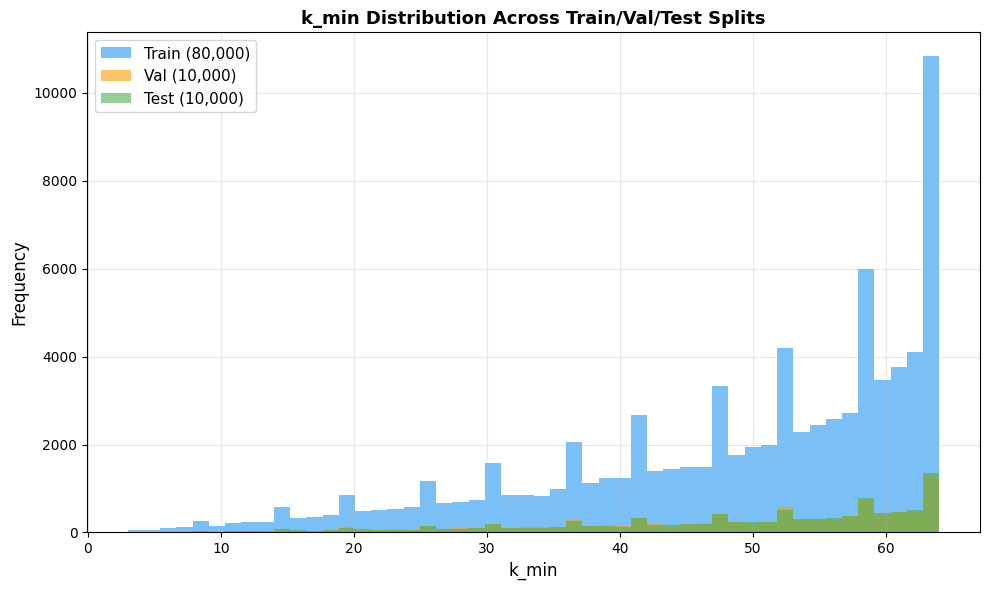

In [20]:
# Cell 4 — Histogram of k_max across train/val/test splits

print(kmin_vals)
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(kmax_vals[train_idx], bins=50, alpha=0.6, label=f'Train ({len(train_idx):,})', color='#2196F3')
ax.hist(kmax_vals[val_idx],   bins=50, alpha=0.6, label=f'Val ({len(val_idx):,})',     color='#FF9800')
ax.hist(kmax_vals[test_idx],  bins=50, alpha=0.6, label=f'Test ({len(test_idx):,})',   color='#4CAF50')

ax.set_xlabel('k_min', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('k_min Distribution Across Train/Val/Test Splits', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmin_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Cell 4 — Pre-trained ResNet50 with 3-output Sigmoid head
#
# conv1 is NOT modified — it keeps the ImageNet pre-trained 3-channel weights.
# The fc layer is replaced with a joint regression head.

class ResNet50JointIN(nn.Module):
    """Pre-trained ResNet50 (ImageNet) with a 3-output Sigmoid regression head."""
    def __init__(self, n_outputs=3, weights=ResNet50_Weights.IMAGENET1K_V2):
        super().__init__()
        self.backbone = models.resnet50(weights=weights)
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_feats, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_outputs),
            nn.Sigmoid()
        )

    def set_backbone_trainable(self, trainable: bool):
        """Freeze/unfreeze everything except the fc head."""
        for name, param in self.backbone.named_parameters():
            if not name.startswith('fc.'):
                param.requires_grad = trainable

    def forward(self, x):
        return self.backbone(x)   # (B, 3)


model = ResNet50JointIN().to(DEVICE)
n_total_p = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ResNet50JointIN  total params    : {n_total_p:,}')
print(f'Trainable (all unfrozen)         : {n_trainable:,}')

ResNet50JointIN  total params    : 24,049,219
Trainable (all unfrozen)         : 24,049,219


In [18]:
# Cell 5 — Loss, training helpers, denorm

class JointRMSELoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
    def forward(self, pred, target):
        mse = (pred - target).pow(2).mean(dim=0)
        return torch.sqrt(mse + self.eps).sum()


def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                loss = criterion(model(X), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
        total += loss.item() * len(X)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total, preds, targets = 0.0, [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred  = model(X)
        total += criterion(pred, y).item() * len(X)
        preds.append(pred.cpu())
        targets.append(y.cpu())
    preds   = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    mae_per = np.mean(np.abs(preds - targets), axis=0)
    return total / len(loader.dataset), mae_per, preds, targets


def denorm(preds_norm, targets_norm):
    p = {'k_min': preds_norm[:, 0]  * (KMIN_HI - KMIN_LO)  + KMIN_LO,
         'k_max': preds_norm[:, 1]  * (KMAX_HI - KMAX_LO)  + KMAX_LO,
         'sigma': np.exp(preds_norm[:, 2]  * (LOG_SIG_HI - LOG_SIG_LO) + LOG_SIG_LO)}
    t = {'k_min': targets_norm[:, 0] * (KMIN_HI - KMIN_LO)  + KMIN_LO,
         'k_max': targets_norm[:, 1] * (KMAX_HI - KMAX_LO)  + KMAX_LO,
         'sigma': np.exp(targets_norm[:, 2] * (LOG_SIG_HI - LOG_SIG_LO) + LOG_SIG_LO)}
    return p, t


print('Loss, helpers, denorm defined.')

Loss, helpers, denorm defined.


In [19]:
# Cell 6 — Smoke test
rng = np.random.RandomState(SEED)
smoke_train = DataLoader(Subset(train_ds, rng.choice(len(train_ds), 2000, replace=False)),
                         batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
smoke_val   = DataLoader(Subset(val_ds,   rng.choice(len(val_ds),    500, replace=False)),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sm = ResNet50JointIN().to(DEVICE)
sm.set_backbone_trainable(False)   # freeze backbone
crit = JointRMSELoss().to(DEVICE)
opt  = optim.AdamW(filter(lambda p: p.requires_grad, sm.parameters()), lr=LR_HEAD)
sc   = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

t0 = time.time()
for ep in range(5):
    tl = train_epoch(sm, smoke_train, crit, opt, sc, DEVICE)
    vl, vm, _, _ = eval_epoch(sm, smoke_val, crit, DEVICE)
    print(f'  Ep {ep+1}/5 | train {tl:.4f} | val {vl:.4f}'
          f' | kmin={vm[0]:.4f} kmax={vm[1]:.4f} sig={vm[2]:.4f}')

ep_time = (time.time() - t0) / 5
print(f'\nTime/epoch (smoke): {ep_time:.1f}s')
print(f'Estimated full training ({EPOCHS} epochs × {len(train_ds):,} imgs):'
      f' ~{ep_time * EPOCHS * len(train_ds) / 2000 / 60:.0f} min')
del sm, opt, sc
if torch.cuda.is_available(): torch.cuda.empty_cache()

  Ep 1/5 | train 0.5153 | val 0.4612 | kmin=0.1006 kmax=0.1363 sig=0.1262
  Ep 2/5 | train 0.4153 | val 0.3586 | kmin=0.0403 kmax=0.1149 sig=0.1152
  Ep 3/5 | train 0.3931 | val 0.3499 | kmin=0.0341 kmax=0.1128 sig=0.1108
  Ep 4/5 | train 0.3900 | val 0.3353 | kmin=0.0335 kmax=0.1074 sig=0.1058
  Ep 5/5 | train 0.3803 | val 0.3297 | kmin=0.0297 kmax=0.1076 sig=0.1033

Time/epoch (smoke): 6.3s
Estimated full training (50 epochs × 80,000 imgs): ~210 min


In [7]:
# Cell 7 — Full training: frozen warm-up → fine-tune (resume-safe)
results_path = OUTPUT_DIR / 'results.json'
best_ckpt    = OUTPUT_DIR / 'best_model.pt'

if results_path.exists():
    print(f'[SKIP] results.json exists — jump to Cell 8')
else:
    model     = ResNet50JointIN().to(DEVICE)
    criterion = JointRMSELoss().to(DEVICE)
    scaler    = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

    history  = {'train_loss': [], 'val_loss': [],
                'val_mae_kmin': [], 'val_mae_kmax': [], 'val_mae_sigma': [],
                'phase': []}
    best_val = float('inf')
    t0       = time.time()

    # Phase 1: frozen backbone, train only the head
    model.set_backbone_trainable(False)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=LR_HEAD, weight_decay=1e-4)
    print(f'Phase 1: frozen backbone ({EPOCHS_FROZEN} epochs)')
    for epoch in range(EPOCHS_FROZEN):
        tl           = train_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        vl, vm, _, _ = eval_epoch(model, val_loader,   criterion, DEVICE)
        for k, v in [('train_loss',tl),('val_loss',vl),
                     ('val_mae_kmin',vm[0]),('val_mae_kmax',vm[1]),('val_mae_sigma',vm[2])]:
            history[k].append(float(v))
        history['phase'].append('frozen')
        print(f'  Ep {epoch+1:2d}/{EPOCHS_FROZEN} | train {tl:.4f} | val {vl:.4f}'
              f' | kmin={vm[0]:.4f} kmax={vm[1]:.4f} sig={vm[2]:.4f}')
        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), best_ckpt)

    # Phase 2: fine-tune all layers
    model.set_backbone_trainable(True)
    optimizer = optim.AdamW([
        {'params': [p for n, p in model.backbone.named_parameters() if not n.startswith('fc.')],
         'lr': LR_FINE, 'weight_decay': 1e-4},
        {'params': model.backbone.fc.parameters(),
         'lr': LR_HEAD, 'weight_decay': 1e-4},
    ])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7)
    print(f'\nPhase 2: fine-tuning ({EPOCHS_FULL} epochs)')
    for epoch in range(EPOCHS_FULL):
        tl           = train_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        vl, vm, _, _ = eval_epoch(model, val_loader,   criterion, DEVICE)
        scheduler.step(vl)
        for k, v in [('train_loss',tl),('val_loss',vl),
                     ('val_mae_kmin',vm[0]),('val_mae_kmax',vm[1]),('val_mae_sigma',vm[2])]:
            history[k].append(float(v))
        history['phase'].append('finetune')
        lr_b = optimizer.param_groups[0]['lr']
        print(f'  Ep {epoch+1:2d}/{EPOCHS_FULL} | train {tl:.4f} | val {vl:.4f}'
              f' | kmin={vm[0]:.4f} kmax={vm[1]:.4f} sig={vm[2]:.4f} | lr {lr_b:.1e}')
        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), best_ckpt)

    training_time = (time.time() - t0) / 60
    print(f'\nTraining done in {training_time:.1f} min  |  best val: {best_val:.4f}')

    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    _, _, y_pred_n, y_true_n = eval_epoch(model, test_loader, criterion, DEVICE)
    y_pred_d, y_true_d = denorm(y_pred_n, y_true_n)
    params  = ['k_min', 'k_max', 'sigma']
    metrics = {p: {'mae':  float(mean_absolute_error(y_true_d[p], y_pred_d[p])),
                   'rmse': float(np.sqrt(mean_squared_error(y_true_d[p], y_pred_d[p]))),
                   'r2':   float(r2_score(y_true_d[p], y_pred_d[p]))}
               for p in params}

    results = {'history': history, 'metrics': metrics,
               'y_true': {p: y_true_d[p].tolist() for p in params},
               'y_pred': {p: y_pred_d[p].tolist() for p in params},
               'training_time_min': training_time,
               'best_val_loss': best_val}
    with open(results_path, 'w') as f:
        json.dump(results, f)
    print(f'Results saved → {results_path}')

Phase 1: frozen backbone (5 epochs)
  Ep  1/5 | train 0.2839 | val 0.2116 | kmin=0.0304 kmax=0.1014 sig=0.0221
  Ep  2/5 | train 0.2583 | val 0.2079 | kmin=0.0282 kmax=0.1006 sig=0.0216
  Ep  3/5 | train 0.2504 | val 0.2055 | kmin=0.0261 kmax=0.0997 sig=0.0226
  Ep  4/5 | train 0.2467 | val 0.1978 | kmin=0.0245 kmax=0.0972 sig=0.0211
  Ep  5/5 | train 0.2447 | val 0.1969 | kmin=0.0244 kmax=0.0961 sig=0.0205

Phase 2: fine-tuning (45 epochs)
  Ep  1/45 | train 0.2229 | val 0.1733 | kmin=0.0175 kmax=0.0838 sig=0.0182 | lr 1.0e-04
  Ep  2/45 | train 0.1944 | val 0.1550 | kmin=0.0155 kmax=0.0795 sig=0.0135 | lr 1.0e-04
  Ep  3/45 | train 0.1844 | val 0.1517 | kmin=0.0139 kmax=0.0747 sig=0.0136 | lr 1.0e-04
  Ep  4/45 | train 0.1759 | val 0.1402 | kmin=0.0122 kmax=0.0704 sig=0.0122 | lr 1.0e-04
  Ep  5/45 | train 0.1701 | val 0.1428 | kmin=0.0112 kmax=0.0723 sig=0.0131 | lr 1.0e-04
  Ep  6/45 | train 0.1653 | val 0.1385 | kmin=0.0110 kmax=0.0690 sig=0.0119 | lr 1.0e-04
  Ep  7/45 | train 0.

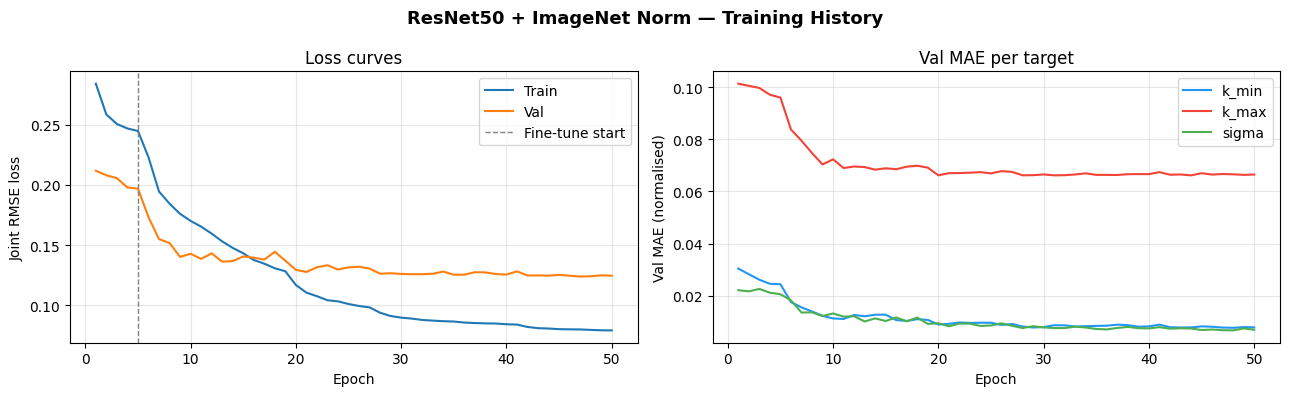

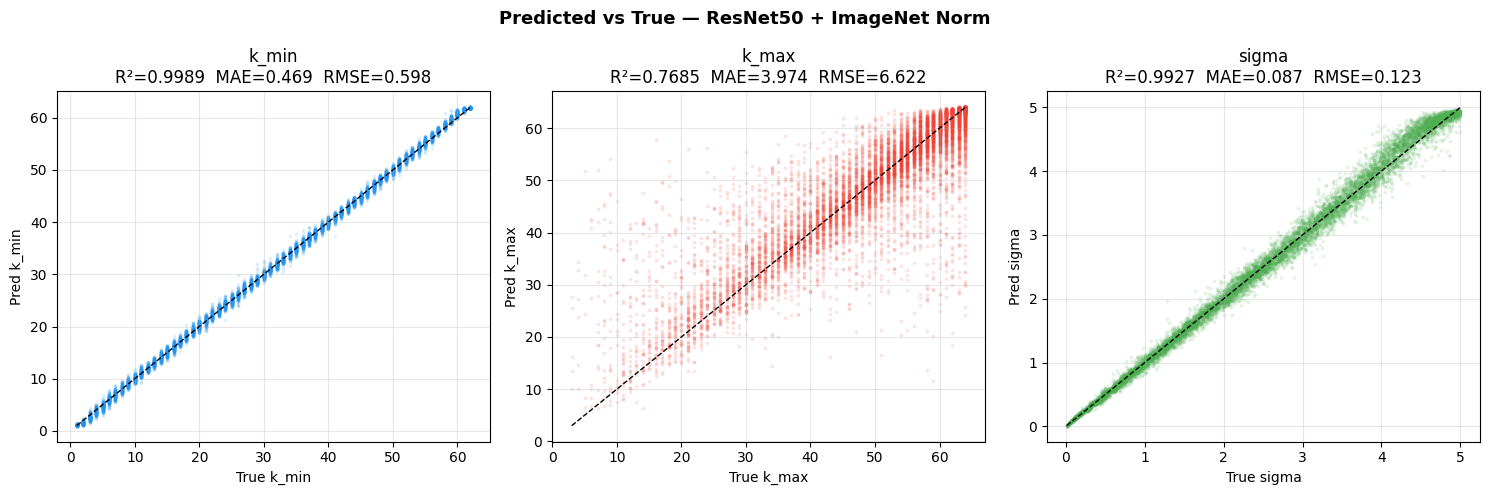


PARAM         MAE     RMSE       R²  |  BASE MAE  BASE R²  Δ MAE
----------------------------------------------------------------------
k_min       0.469    0.598   0.9989  |     0.475   0.9987  -0.006
k_max       3.974    6.622   0.7685  |     3.917   0.7597  +0.057
sigma       0.087    0.123   0.9927  |     0.080   0.9937  +0.007


In [8]:
# Cell 8 — Load results + evaluation plots
if 'results' not in globals():
    with open(results_path, 'r') as f:
        results = json.load(f)
    print(f'Loaded results from {results_path}')

params = ['k_min', 'k_max', 'sigma']
colors = {'k_min': '#2196F3', 'k_max': '#F44336', 'sigma': '#4CAF50'}

# Training curves
h = results['history']
ep_range = range(1, len(h['train_loss']) + 1)
phases   = h.get('phase', [])
switch   = sum(1 for p in phases if p == 'frozen')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ep_range, h['train_loss'], label='Train')
axes[0].plot(ep_range, h['val_loss'],   label='Val')
if switch:
    axes[0].axvline(switch, color='gray', linestyle='--', linewidth=1, label='Fine-tune start')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Joint RMSE loss')
axes[0].set_title('Loss curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for p, key in [('k_min','val_mae_kmin'),('k_max','val_mae_kmax'),('sigma','val_mae_sigma')]:
    if key in h:
        axes[1].plot(ep_range, h[key], label=p, color=colors[p])
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val MAE (normalised)')
axes[1].set_title('Val MAE per target'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('ResNet50 + ImageNet Norm — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, param in zip(axes, params):
    yt = np.array(results['y_true'][param])
    yp = np.array(results['y_pred'][param])
    m  = results['metrics'][param]
    ax.scatter(yt, yp, alpha=0.10, s=3, color=colors[param], rasterized=True)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel(f'True {param}'); ax.set_ylabel(f'Pred {param}')
    ax.set_title(f'{param}\nR²={m["r2"]:.4f}  MAE={m["mae"]:.3f}  RMSE={m["rmse"]:.3f}')
    ax.grid(True, alpha=0.3)
plt.suptitle('Predicted vs True — ResNet50 + ImageNet Norm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table with comparison to joint_regression baseline
ranges = {'k_min': KMIN_HI-KMIN_LO, 'k_max': KMAX_HI-KMAX_LO,
          'sigma': np.exp(LOG_SIG_HI)-np.exp(LOG_SIG_LO)}
baseline = {'k_min': {'mae': 0.475, 'rmse': 0.641, 'r2': 0.9987},
            'k_max': {'mae': 3.917, 'rmse': 6.747, 'r2': 0.7597},
            'sigma': {'mae': 0.080, 'rmse': 0.114, 'r2': 0.9937}}

print(f"\n{'='*70}")
print(f"{'PARAM':<8} {'MAE':>8} {'RMSE':>8} {'R²':>8}  | {'BASE MAE':>9} {'BASE R²':>8}  Δ MAE")
print(f"{'-'*70}")
for p, m in results['metrics'].items():
    b   = baseline[p]
    pct = 100 * m['mae'] / ranges[p]
    delta = m['mae'] - b['mae']
    sign  = '+' if delta > 0 else ''
    print(f"{p:<8} {m['mae']:>8.3f} {m['rmse']:>8.3f} {m['r2']:>8.4f}  | "
          f"{b['mae']:>9.3f} {b['r2']:>8.4f}  {sign}{delta:.3f}")
print(f"{'='*70}")

In [9]:
# Cell 9 — Inference on FITS observational images
#
# Applies the same ImageNet-norm preprocessing to the GASS HI images
# and runs the trained model on each 2D image (full integration + 5 channels).

from astropy.io import fits
import warnings
from astropy.wcs import FITSFixedWarning
warnings.filterwarnings('ignore', category=FITSFixedWarning)

FITS_PATH = PROJECT_ROOT / 'observational_images' / 'gass_314_-28_1774393621.fits.gz'

# Load FITS cube
with fits.open(FITS_PATH) as hdul:
    cube = hdul[0].data.astype(np.float32)   # (1201, 125, 125)

n_v = len(cube)
data_2d  = np.sum(cube, axis=0)
data_ch1 = np.sum(cube[0:n_v//5], axis=0)
data_ch2 = np.sum(cube[n_v//5+1:2*n_v//5], axis=0)
data_ch3 = np.sum(cube[2*n_v//5+1:3*n_v//5], axis=0)
data_ch4 = np.sum(cube[3*n_v//5+1:4*n_v//5], axis=0)
data_ch5 = np.sum(cube[4*n_v//5+1:5*n_v//5], axis=0)


def preprocess_fits(img2d: np.ndarray, img_p1: float, img_p99: float) -> torch.Tensor:
    """Apply same preprocessing as training: clip → [0,1] → 3ch → ImageNet norm."""
    img   = img2d.astype(np.float32)
    img   = np.clip((img - img_p1) / (img_p99 - img_p1 + 1e-8), 0.0, 1.0)
    t     = torch.from_numpy(img).unsqueeze(0).repeat(3, 1, 1)   # (3, H, W)
    t     = (t - IN_MEAN) / IN_STD                                # ImageNet norm
    return t.unsqueeze(0)                                         # (1, 3, H, W)


# Compute p1/p99 from the full cube (use same stats as the reference image)
fits_p1  = float(np.percentile(data_2d, 1))
fits_p99 = float(np.percentile(data_2d, 99))

# Load best model
if 'model' not in globals():
    model = ResNet50JointIN().to(DEVICE)
if best_ckpt.exists():
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model.eval()


@torch.no_grad()
def predict_fits(img2d):
    t   = preprocess_fits(img2d, fits_p1, fits_p99).to(DEVICE)
    out = model(t).cpu().numpy()[0]   # (3,)
    return {
        'k_min':  float(out[0] * (KMIN_HI - KMIN_LO) + KMIN_LO),
        'k_max':  float(out[1] * (KMAX_HI - KMAX_LO) + KMAX_LO),
        'sigma':  float(np.exp(out[2] * (LOG_SIG_HI - LOG_SIG_LO) + LOG_SIG_LO)),
    }


obs_images = {
    'full integration': data_2d,
    'channel 1 (v1)':  data_ch1,
    'channel 2 (v2)':  data_ch2,
    'channel 3 (v3)':  data_ch3,
    'channel 4 (v4)':  data_ch4,
    'channel 5 (v5)':  data_ch5,
}

print(f'FITS file : {FITS_PATH.name}')
print(f'Cube shape: {cube.shape}')
print(f'\n{"Image":<22}  {"k_min":>8}  {"k_max":>8}  {"sigma":>8}')
print('-' * 50)
for label, img in obs_images.items():
    pred = predict_fits(img)
    print(f"{label:<22}  {pred['k_min']:>8.2f}  {pred['k_max']:>8.2f}  {pred['sigma']:>8.3f}")

FITS file : gass_314_-28_1774393621.fits.gz
Cube shape: (1201, 125, 125)

Image                      k_min     k_max     sigma
--------------------------------------------------
full integration            1.60     36.63     4.822
channel 1 (v1)              1.00     26.76     5.000
channel 2 (v2)              1.00     26.76     5.000
channel 3 (v3)              1.58     34.87     4.845
channel 4 (v4)              1.00     26.76     5.000
channel 5 (v5)              1.00     26.76     5.000
